In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [53]:
df = pd.read_csv("housing.csv")

In [54]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA

In [55]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [56]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())

In [57]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

<Axes: xlabel='total_bedrooms', ylabel='median_house_value'>

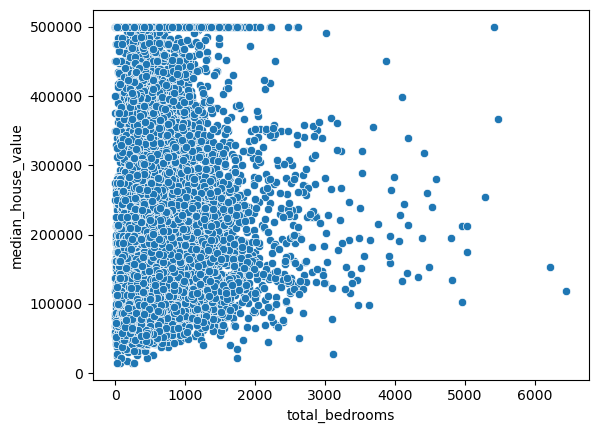

In [58]:
sns.scatterplot(x=df["total_bedrooms"], y=df["median_house_value"])

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

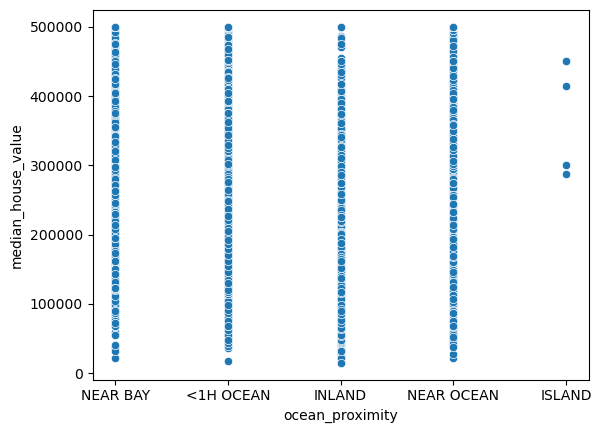

In [59]:
sns.scatterplot(x=df["ocean_proximity"], y=df["median_house_value"])

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

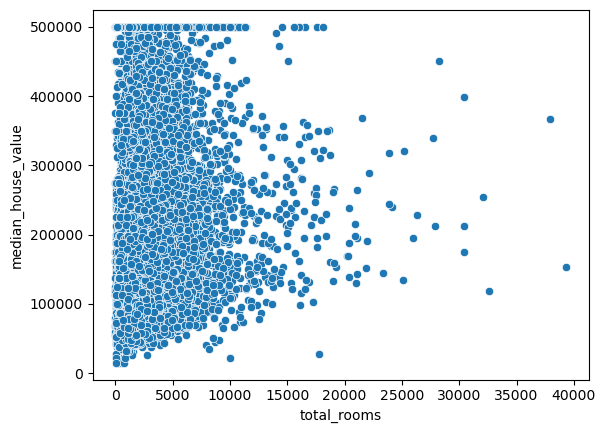

In [60]:
sns.scatterplot(x=df["total_rooms"], y=df["median_house_value"])

In [61]:
X= df.drop(columns=["median_house_value"])
y= df["median_house_value"]
X=pd.get_dummies(X, columns=["ocean_proximity"], drop_first= False, dtype=int)

In [62]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [63]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,0,1,0


In [64]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [65]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [66]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [67]:
y_pred= model.predict(X_test_scaled)

In [68]:
y_pred

array([ 64743.52609041, 134535.52609041, 265359.52609041, ...,
       439399.52609041, 120903.52609041, 183527.52609041])

In [69]:
# Evaluate
from sklearn.metrics import  r2_score,mean_absolute_error,root_mean_squared_error
r2_score= r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)


print(f"r2_score:{r2_score}")
print(f"MAE: {mae}")


r2_score:0.6256528550424283
MAE: 50697.456568554204


In [70]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

In [71]:
rmse

70039.12190563568

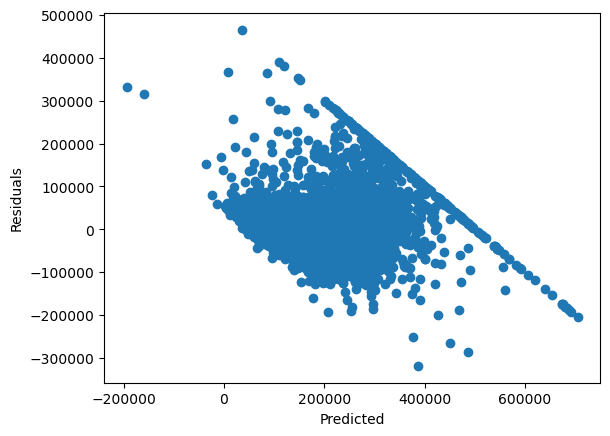

In [72]:
residuals= y_test - y_pred
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()